# 05 · Fail Prediction — and why validation strategy matters more than the algorithm

Code: [`src/model.py`](../src/model.py), tests: [`tests/test_model.py`](../tests/test_model.py).
Heavy computation runs as a script (`python -m src.model`); this notebook reads its outputs.

**Setup**
- Input: the 30 sensors selected in Step 4. Train = 19 Jul → 29 Sep (1175 units, 80 fails); test = 29 Sep → 17 Oct (392 units, 24 fails).
- Candidates: Logistic regression, Logistic + SMOTE, Random forest, Balanced random forest, Histogram gradient boosting.
  Each one handles the 6.6% fail rate through class weights or resampling.
- Threshold: tuned to minimise the balanced error rate (BER) on out-of-fold train predictions, then frozen.

**Transparency note.** The first run (v1) chose the model with ordinary *stratified* cross-validation. It picked
gradient boosting (CV BER 24%), which then scored **BER 49% on the test period**, no better than a coin flip.
Diagnosing that failure is the main content of this notebook. The final protocol (v2) chooses the model with
**forward (time-aware) validation** inside the train period.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve
import warnings
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
FIG_DIR = ROOT / "reports" / "figures"
sns.set_theme(style="whitegrid", context="notebook")
PASS_C, FAIL_C, INK = "#2a9d8f", "#e76f51", "#264653"

cv = pd.read_csv(ROOT / "data/processed/model_cv_comparison.csv")
test_cmp = pd.read_csv(ROOT / "data/processed/model_test_comparison.csv")
preds = pd.read_csv(ROOT / "data/processed/predictions.csv", parse_dates=["timestamp"])
wf = pd.read_csv(ROOT / "data/processed/walk_forward.csv", parse_dates=["timestamp", "train_until"])
card = json.load(open(ROOT / "models/model_card.json"))
train = pd.read_csv(ROOT / "data/processed/train_clean.csv", parse_dates=["timestamp"])
test = pd.read_csv(ROOT / "data/processed/test_clean.csv", parse_dates=["timestamp"])
print(f"Final model: {card['model']} | threshold {card['threshold']:.3f} | {len(card['features'])} sensors")

Final model: logistic | threshold 0.338 | 30 sensors


## 1. Two validation strategies, two different winners

,model,ber_stratified,ber_forward,ber_test
4,logistic,29.8%,29.2%,41.8%
2,random_forest,25.2%,31.8%,47.6%
0,hist_gb,24.3%,37.2%,48.8%
1,balanced_rf,24.9%,37.7%,47.6%
3,logistic_smote,29.0%,38.1%,43.6%


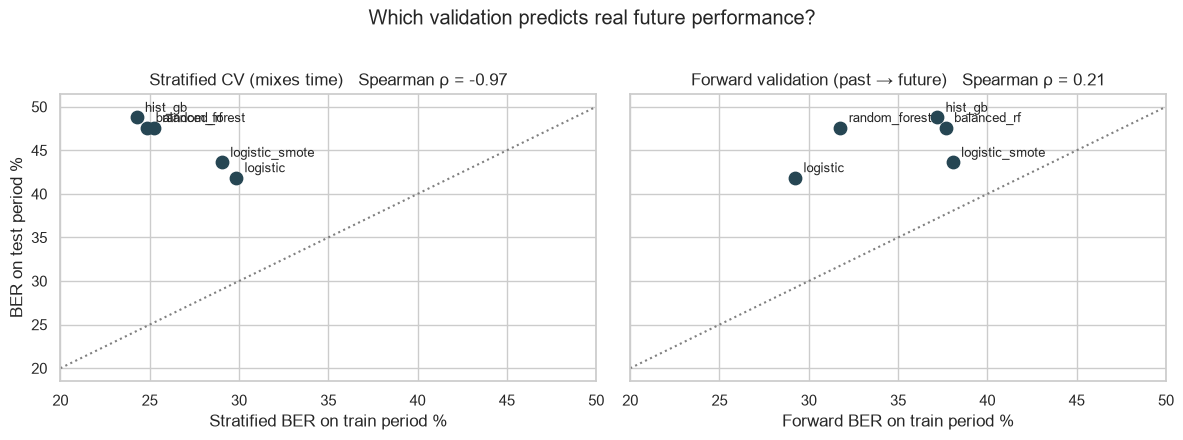

In [2]:
test_ber = {a.split(" (")[0]: b for a, b in zip(test_cmp.approach, test_cmp.ber) if "(30 sensors)" in a}
cmp = cv[["model", "ber_stratified", "ber_forward"]].assign(ber_test=lambda d: d.model.map(test_ber))
display(cmp.sort_values("ber_forward").style.format("{:.1%}", subset=["ber_stratified", "ber_forward", "ber_test"])
        .highlight_min(subset=["ber_stratified", "ber_forward", "ber_test"], color="#d8f3dc"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), sharey=True)
for ax, col, title in [(axes[0], "ber_stratified", "Stratified CV (mixes time)"),
                       (axes[1], "ber_forward", "Forward validation (past → future)")]:
    ax.scatter(cmp[col] * 100, cmp.ber_test * 100, s=80, color=INK)
    for _, r in cmp.iterrows():
        ax.annotate(r.model, (r[col] * 100, r.ber_test * 100), textcoords="offset points", xytext=(6, 4), fontsize=9)
    rho = cmp[[col, "ber_test"]].corr("spearman").iloc[0, 1]
    ax.set(xlabel=f"{col.replace('ber_', '').title()} BER on train period %", title=f"{title}   Spearman ρ = {rho:.2f}")
    ax.plot([20, 50], [20, 50], ls=":", color="grey")
    ax.set_xlim(20, 50)
axes[0].set_ylabel("BER on test period %")
fig.suptitle("Which validation predicts real future performance?", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "05_validation_vs_test.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:**
- **Stratified CV** ranks gradient boosting and the random forests best (BER ≈ 24–25%), but on the test
  period they are the **worst** (48–49%). Its ranking is almost perfectly **inverted** relative to reality (Spearman ρ = −0.97).
- **Forward validation** (train on Jul → mid-Sep, validate on the rest of Sep) ranks **logistic regression**
  first, and it is also the best 30-sensor model on the test period. Its overall correlation with the test
  ranking is only weak (ρ = 0.21, five models and 24 test failures), but it picks the right winner.
- Every model does worse on the future than any train-period estimate promised, because the process drifts.

## 2. Why? The failure signature changes over time

Failures per period: {'Jul–Aug': 65, 'Sep': 15, 'Oct (test)': 24}


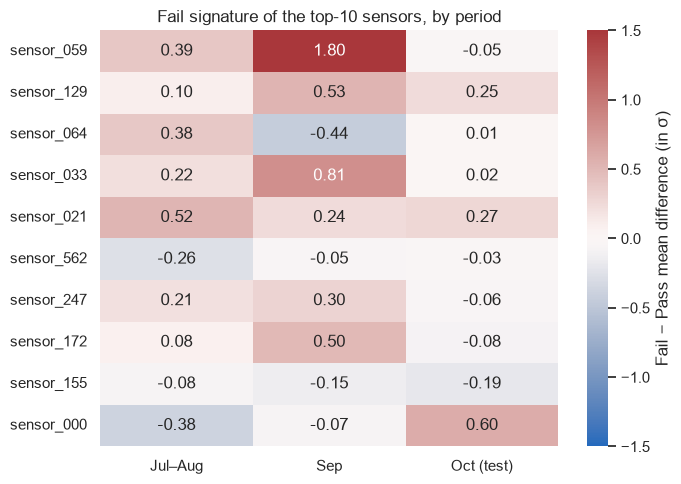

In [3]:
feats = card["features"][:10]
periods = {"Jul–Aug": train[train.timestamp < "2008-09-01"], "Sep": train[train.timestamp >= "2008-09-01"], "Oct (test)": test}
def smd(d, s):
    return (d.loc[d.fail == 1, s].mean() - d.loc[d.fail == 0, s].mean()) / d[s].std()
drift = pd.DataFrame({p: [smd(d, s) for s in feats] for p, d in periods.items()}, index=feats)
print("Failures per period:", {p: int(d.fail.sum()) for p, d in periods.items()})

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(drift, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1.5, vmax=1.5, ax=ax,
            cbar_kws={"label": "Fail − Pass mean difference (in σ)"})
ax.set_title("Fail signature of the top-10 sensors, by period")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_concept_drift.png", dpi=150)
plt.show()

**This is concept drift.** `sensor_059`, the #1 sensor in every train-period analysis, separates failures
strongly in September (1.8σ) and **not at all in October** (−0.05σ). `sensor_000` even flips sign. The October
failures come from a *different mechanism* than the ones the model learned.

Stratified CV shuffles July, August and September units together, so the model is always validated on
failure types it has already seen. Flexible models (boosting, forests) memorise those period-specific
patterns and look great in CV, then fail on the future. The simpler, regularised logistic model generalises
a little better.

## 3. Final model on the test period

,value,95% CI
BER,0.418,30.6% – 50.9%
Recall (fails caught),0.375,20% – 58%
Specificity,0.788,
Precision,0.103,
ROC-AUC,0.593,0.48 – 0.71
PR-AUC,0.086,0.053 – 0.156


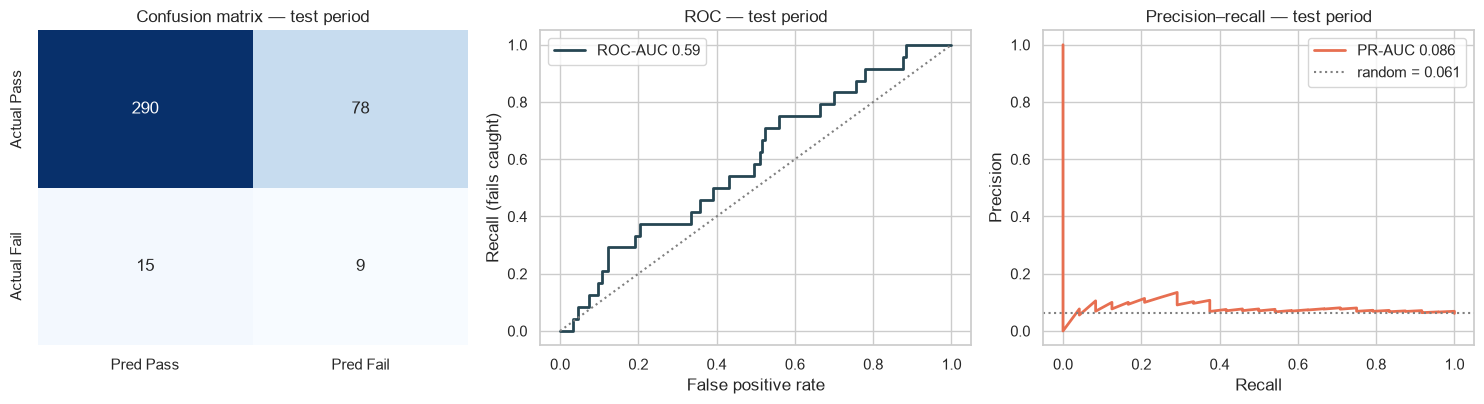

In [4]:
t = card["test"]; ci = card["test_ci95"]
summary = pd.DataFrame({
    "value": [t["ber"], t["recall_fail"], t["specificity"], t["precision_fail"], t["roc_auc"], t["pr_auc"]],
    "95% CI": [f"{ci['ber'][0]:.1%} – {ci['ber'][1]:.1%}", f"{ci['recall_fail'][0]:.0%} – {ci['recall_fail'][1]:.0%}",
               "", "", f"{ci['roc_auc'][0]:.2f} – {ci['roc_auc'][1]:.2f}", f"{ci['pr_auc'][0]:.3f} – {ci['pr_auc'][1]:.3f}"],
}, index=["BER", "Recall (fails caught)", "Specificity", "Precision", "ROC-AUC", "PR-AUC"])
display(summary.style.format({"value": "{:.3f}"}))

te = preds[preds.period == "test"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
cm = np.array([[t["tn"], t["fp"]], [t["fn"], t["tp"]]])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Pred Pass", "Pred Fail"], yticklabels=["Actual Pass", "Actual Fail"])
axes[0].set_title("Confusion matrix — test period")
fpr, tpr, _ = roc_curve(te.fail, te.fail_prob)
axes[1].plot(fpr, tpr, color=INK, lw=2, label=f"ROC-AUC {t['roc_auc']:.2f}")
axes[1].plot([0, 1], [0, 1], ls=":", color="grey")
axes[1].set(xlabel="False positive rate", ylabel="Recall (fails caught)", title="ROC — test period")
axes[1].legend()
prec, rec, _ = precision_recall_curve(te.fail, te.fail_prob)
axes[2].plot(rec, prec, color=FAIL_C, lw=2, label=f"PR-AUC {t['pr_auc']:.3f}")
axes[2].axhline(te.fail.mean(), ls=":", color="grey", label=f"random = {te.fail.mean():.3f}")
axes[2].set(xlabel="Recall", ylabel="Precision", title="Precision–recall — test period")
axes[2].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "05_test_performance.png", dpi=150)
plt.show()

## 4. Against the baselines

In [5]:
show = test_cmp[["approach", "ber", "recall_fail", "specificity", "precision_fail", "roc_auc"]]
show.style.format({c: "{:.1%}" for c in ["ber", "recall_fail", "specificity", "precision_fail"]} | {"roc_auc": "{:.3f}"}) \
    .highlight_min(subset=["ber"], color="#d8f3dc")

,approach,ber,recall_fail,specificity,precision_fail,roc_auc
0,logistic (30 sensors) - FINAL,41.8%,37.5%,78.8%,10.3%,0.593
1,logistic_smote (30 sensors),43.6%,25.0%,87.8%,11.8%,0.607
2,random_forest (30 sensors),47.6%,8.3%,96.5%,13.3%,0.532
3,balanced_rf (30 sensors),47.6%,8.3%,96.5%,13.3%,0.566
4,hist_gb (30 sensors),48.8%,12.5%,89.9%,7.5%,0.549
5,logistic (all 272 sensors),37.5%,54.2%,70.9%,10.8%,0.681
6,logistic weekly walk-forward retraining,42.7%,29.2%,85.4%,11.3%,0.594
7,SPC alarm rule (Step 3),46.9%,20.8%,85.3%,8.5%,0.531
8,Always predict Pass,50.0%,0.0%,100.0%,0.0%,0.500


Reading the table (24 test failures, so differences under ~7 percentage points are within noise):
- The final model catches **9 of 24 failures** (38%) while flagging ~22% of units: better than the SPC
  rule (21% recall) and than always predicting Pass, but a weak classifier overall (ROC-AUC 0.59, with a CI that touches 0.5).
- **Weekly walk-forward retraining** does not rescue it (BER 42.7%). Adding recent weeks cannot help when the
  new failure mode appears only a handful of times before it has to be predicted.
- *Logistic on all 272 sensors* scores best on the test (37.5%). It is **not** adopted: that choice would
  be made by looking at the test set. It does hint that a broader, regularised sensor set is more robust
  to drift than a small set tuned to past failure modes. Worth re-checking on the next batch of data.

## 5. Walk-forward retraining week by week

In [6]:
wk = wf.assign(week=wf.train_until.dt.date).groupby("week").agg(
    units=("fail", "size"), fails=("fail", "sum"), flagged=("predicted_fail", "sum"),
    caught=("predicted_fail", lambda s: int((s & wf.loc[s.index, "fail"]).sum())))
wk["recall"] = (wk.caught / wk.fails).where(wk.fails > 0)
display(wk)

,units,fails,flagged,caught,recall
week,,,,,
2008-09-29,169,15,40,5,0.333333
2008-10-06,138,8,10,1,0.125000
2008-10-13,94,1,12,1,1.000000


## 6. What it means for the fab — risk ranking instead of hard decisions

,inspect top,fails caught,share of fails,lift vs random
0,10% (39 units),3/24,12%,1.25×
1,20% (78 units),8/24,33%,1.67×
2,30% (118 units),9/24,38%,1.25×
3,50% (196 units),14/24,58%,1.17×


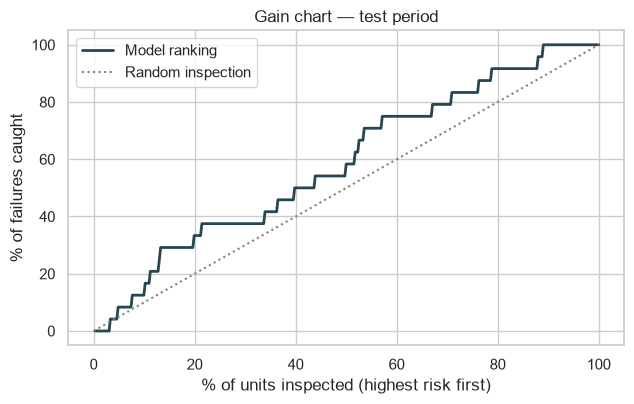

In [7]:
te_sorted = te.sort_values("fail_prob", ascending=False).reset_index(drop=True)
te_sorted["inspected_share"] = (np.arange(len(te_sorted)) + 1) / len(te_sorted)
te_sorted["fails_caught_share"] = te_sorted.fail.cumsum() / te_sorted.fail.sum()
rows = []
for share in [0.1, 0.2, 0.3, 0.5]:
    n = int(round(share * len(te_sorted)))
    caught = te_sorted.fail.iloc[:n].sum()
    rows.append({"inspect top": f"{share:.0%} ({n} units)", "fails caught": f"{caught}/{te_sorted.fail.sum()}",
                 "share of fails": caught / te_sorted.fail.sum(), "lift vs random": (caught / te_sorted.fail.sum()) / share})
display(pd.DataFrame(rows).style.format({"share of fails": "{:.0%}", "lift vs random": "{:.2f}×"}))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(te_sorted.inspected_share * 100, te_sorted.fails_caught_share * 100, color=INK, lw=2, label="Model ranking")
ax.plot([0, 100], [0, 100], ls=":", color="grey", label="Random inspection")
ax.set(xlabel="% of units inspected (highest risk first)", ylabel="% of failures caught",
       title="Gain chart — test period")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "05_gain_chart.png", dpi=150)
plt.show()

Used as a **risk ranking**, the model gives a modest lift over random inspection. That is enough to put
extra metrology on the riskiest units, but not enough to scrap units automatically. The model card records
this intended use.

## 7. Takeaways

| # | Finding | Lesson |
|---|---|---|
| 1 | Stratified CV promised BER 24%; the same model scored 49% on the future. Its model ranking was inverted (ρ = −0.97) | Random CV is misleading on drifting manufacturing data |
| 2 | Forward validation picked the model that really was best on the test | Validate the way the model will be used: past → future |
| 3 | `sensor_059` goes from 1.8σ fail signal (Sep) to none (Oct) | **Concept drift**: failure mechanisms change, so models need monitoring and retraining |
| 4 | Final model: BER 41.8% (CI 31–51%), catches 9/24 failures, ROC-AUC 0.59 | Honest, modest performance; use for risk ranking, not auto-scrap |
| 5 | Retraining weekly did not fix it | New failure modes need new labelled examples, or unsupervised detection (Step 6) |

**Artefacts:** `models/fail_model.joblib` (raw 590 sensors → cleaning → 30 sensors → logistic),
`models/model_card.json` (metrics, CIs, intended use), `data/processed/predictions.csv` (probability and risk band per unit).